``Open in colab``

# Práctica 1: Estudio comparativo de algoritmos en un problema de k-armed bandit

**Descripción**: Description: El experimento compara el rendimiento de algoritmos epsilon-greedy en un problema de k-armed bandit. Se generan gráficas de recompensas promedio para cada algoritmo.

**Asignatura**: Extensiones de Machine Learning, 2025/2026

**Autores**: 
* Alberto Ortega Pastor
* Manuel Salas Díaz
* Lola Conde Herrera

**Máster de Inteligencia Artificial**

**Facultad de Informática**

-----

## Preparación del entorno

In [ ]:
!git clone https://github.com/Loicsav/SalasOrtegaConde1.git
%cd SalasOrtegaConde1

!pip install -r requirements.txt

In [1]:
import sys
import numpy as np
from typing import List

from algorithms import Algorithm, EpsilonGreedy
from arms import ArmNormal, Bandit, ArmBernoulli, ArmBinomial
from plotting import plot_average_rewards, plot_optimal_selections, plot_arm_statistics, plot_regret

In [2]:
seed = 42
np.random.seed(seed)

k = 10  # Número de brazos
steps = 1000  # Número de pasos que se ejecutarán cada algoritmo
runs = 500  # Número de ejecuciones

# Algoritmo  ε-greedy

## Experimentos

In [3]:
def run_experiment(bandit: Bandit, algorithms: List[Algorithm], steps: int, runs: int):

    optimal_arm = bandit.optimal_arm  # Necesario para calcular el porcentaje de selecciones óptimas.

    rewards = np.zeros((len(algorithms), steps)) # Matriz para almacenar las recompensas promedio.

    optimal_selections = np.zeros((len(algorithms), steps))  # Matriz para almacenar el porcentaje de selecciones óptimas.

    regrets = np.zeros((len(algorithms), steps))  # Matriz para almacenar el regret acumulado.

    for run in range(runs):
        current_bandit = Bandit(arms=bandit.arms)

        for algo in algorithms:
            algo.reset() # Reiniciar los valores de los algoritmos.

        total_rewards_per_algo = np.zeros(len(algorithms)) # Acumulador de recompensas por algoritmo. Necesario para calcular el promedio.

        for step in range(steps):
            for idx, algo in enumerate(algorithms):
                chosen_arm = algo.select_arm() # Seleccionar un brazo según la política del algoritmo.
                reward = current_bandit.pull_arm(chosen_arm) # Obtener la recompensa del brazo seleccionado.
                algo.update(chosen_arm, reward) # Actualizar el valor estimado del brazo seleccionado.

                rewards[idx, step] += reward # Acumular la recompensa obtenida en la matriz rewards para el algoritmo idx en el paso step.
                total_rewards_per_algo[idx] += reward # Acumular la recompensa obtenida en total_rewards_per_algo para el algoritmo idx.

                regrets[idx, step] += (current_bandit.get_expected_value(optimal_arm) - reward) # Acumular el regret obtenido en la matriz regrets para el algoritmo idx en el paso step.

                if chosen_arm == optimal_arm:
                    optimal_selections[idx, step] += 1


    rewards /= runs
    regrets /= runs
    optimal_selections /= runs
    
    # Recopilar estadísticas de brazos para cada algoritmo
    arm_stats = []
    for algo in algorithms:
        arm_data = [
            {
                'arm': i + 1,  # Número del brazo (1 al k)
                'counts': int(algo.counts[i]),  # Número de veces seleccionado
                'values': float(algo.values[i])  # Recompensa promedio estimada
            }
            for i in range(algo.k)
        ]
        arm_stats.append(arm_data)

    return rewards, optimal_selections, arm_stats, regrets

## ``Experimento distribución Normal``

In [4]:
# Creación del bandit
bandit = Bandit(arms=ArmNormal.generate_arms(k)) # Generar un bandido con k brazos de distribución normal
print(bandit)

optimal_arm = bandit.optimal_arm
print(f"Optimal arm: {optimal_arm + 1} with expected reward={bandit.get_expected_value(optimal_arm)}")

# Definir los algoritmos a comparar. En este caso son 3 algoritmos epsilon-greedy con diferentes valores de epsilon.
algorithms = [EpsilonGreedy(k=k, epsilon=0), EpsilonGreedy(k=k, epsilon=0.01), EpsilonGreedy(k=k, epsilon=0.1)]

# Ejecutar el experimento y obtener las recompensas promedio, porcentaje de selecciones óptimas y estadísticas de brazos
rewards, optimal_selections, arm_stats, regrets = run_experiment(bandit, algorithms, steps, runs)

Bandit with 10 arms: ArmNormal(mu=1.52, sigma=1.0), ArmNormal(mu=2.4, sigma=1.0), ArmNormal(mu=1.19, sigma=1.0), ArmNormal(mu=4.37, sigma=1.0), ArmNormal(mu=6.39, sigma=1.0), ArmNormal(mu=7.59, sigma=1.0), ArmNormal(mu=8.8, sigma=1.0), ArmNormal(mu=9.56, sigma=1.0), ArmNormal(mu=6.41, sigma=1.0), ArmNormal(mu=7.37, sigma=1.0)
Optimal arm: 8 with expected reward=9.56


### Visualización

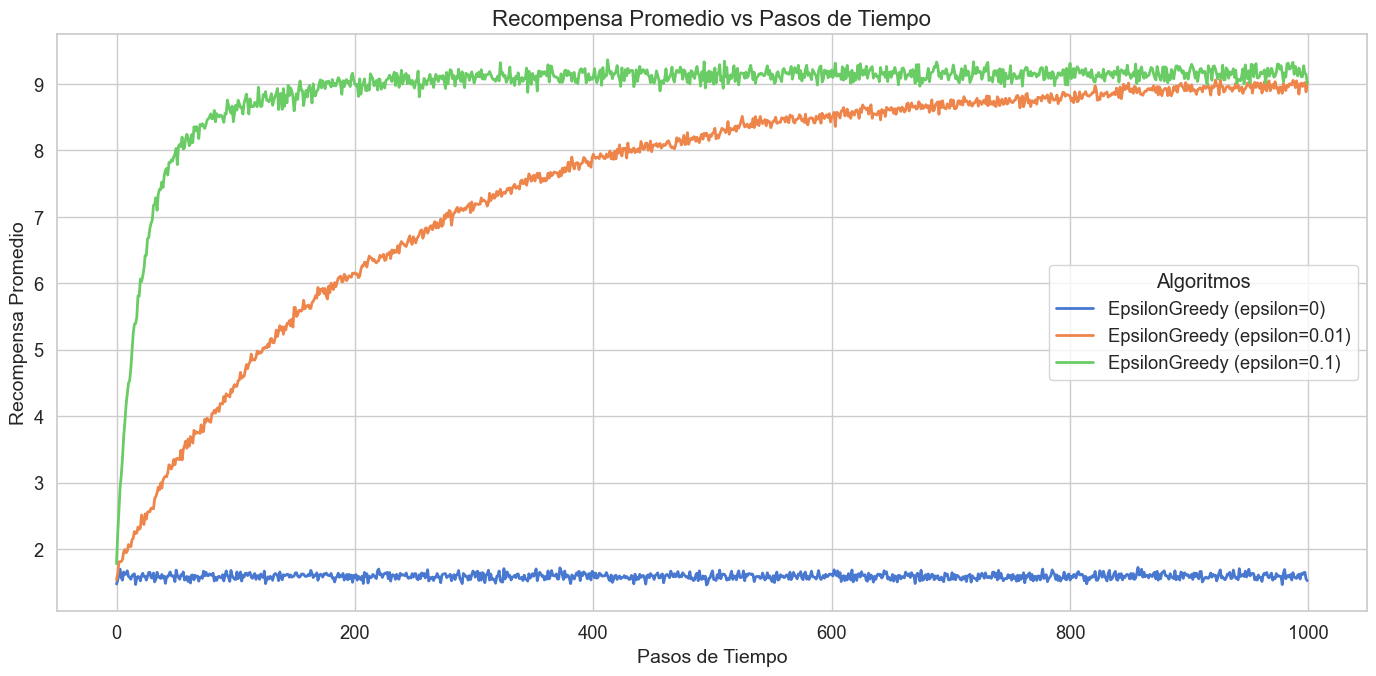

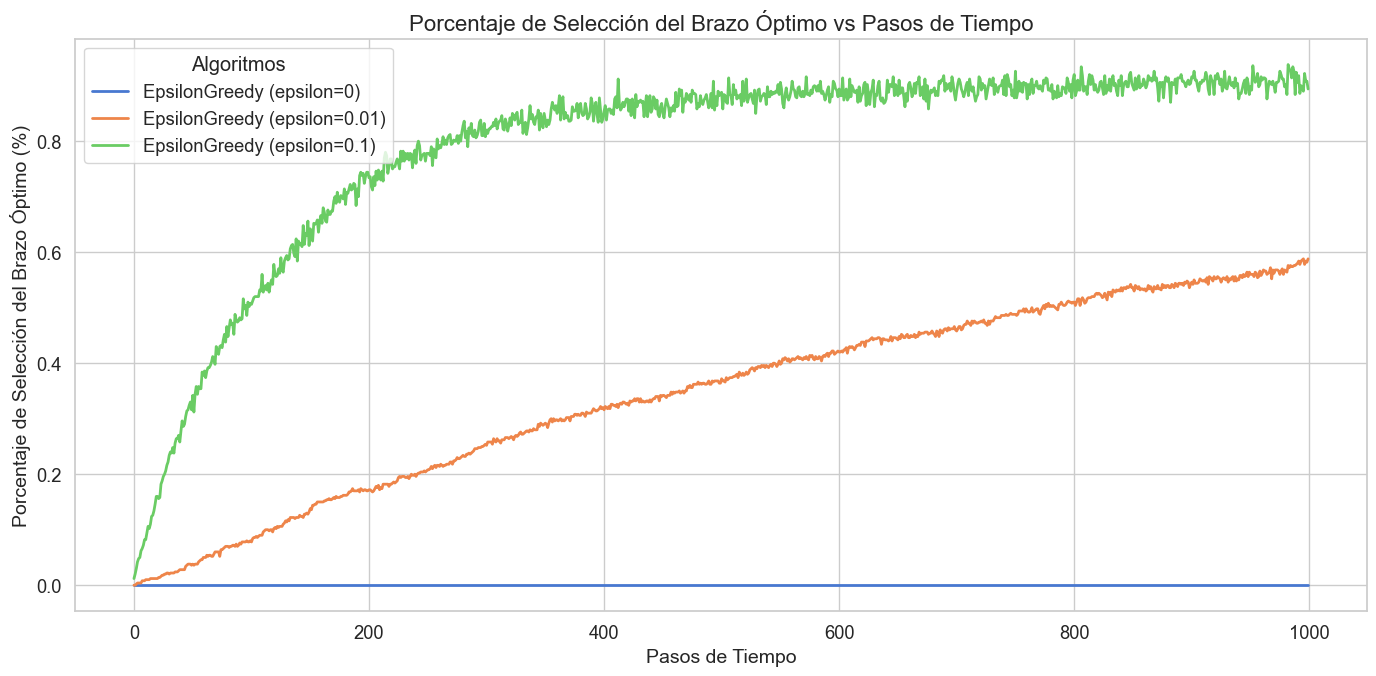


Estadísticas de brazos - EpsilonGreedy (epsilon=0)
Brazo 1: Recompensa Promedio = 1.4895, Selecciones = 1000 (ÓPTIMO)
Brazo 2: Recompensa Promedio = 0.0000, Selecciones = 0
Brazo 3: Recompensa Promedio = 0.0000, Selecciones = 0
Brazo 4: Recompensa Promedio = 0.0000, Selecciones = 0
Brazo 5: Recompensa Promedio = 0.0000, Selecciones = 0
Brazo 6: Recompensa Promedio = 0.0000, Selecciones = 0
Brazo 7: Recompensa Promedio = 0.0000, Selecciones = 0
Brazo 8: Recompensa Promedio = 0.0000, Selecciones = 0
Brazo 9: Recompensa Promedio = 0.0000, Selecciones = 0
Brazo 10: Recompensa Promedio = 0.0000, Selecciones = 0


c:\Users\loics\Desktop\Universidad\MasterIA\EML\SalasOrtegaConde1\plotting\plotting.py:136: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(x_labels, rotation=45, ha="right", fontsize=10)


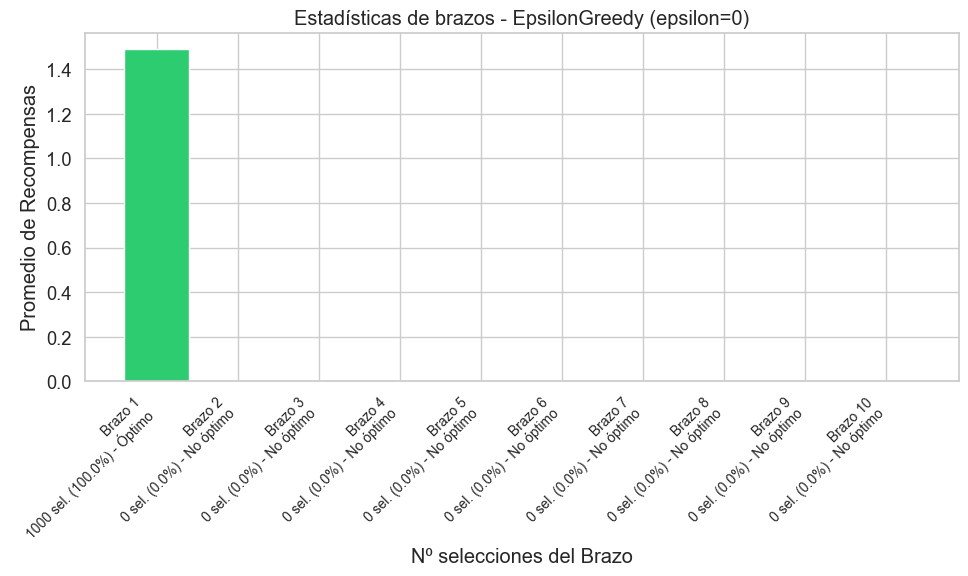


Estadísticas de brazos - EpsilonGreedy (epsilon=0.01)
Brazo 1: Recompensa Promedio = 0.7970, Selecciones = 3
Brazo 2: Recompensa Promedio = 2.2475, Selecciones = 131
Brazo 3: Recompensa Promedio = 0.0000, Selecciones = 0
Brazo 4: Recompensa Promedio = 4.7205, Selecciones = 1
Brazo 5: Recompensa Promedio = 6.0625, Selecciones = 1
Brazo 6: Recompensa Promedio = 0.0000, Selecciones = 0
Brazo 7: Recompensa Promedio = 8.8719, Selecciones = 556 (ÓPTIMO)
Brazo 8: Recompensa Promedio = 8.7574, Selecciones = 4
Brazo 9: Recompensa Promedio = 0.0000, Selecciones = 0
Brazo 10: Recompensa Promedio = 7.4683, Selecciones = 304


c:\Users\loics\Desktop\Universidad\MasterIA\EML\SalasOrtegaConde1\plotting\plotting.py:136: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(x_labels, rotation=45, ha="right", fontsize=10)


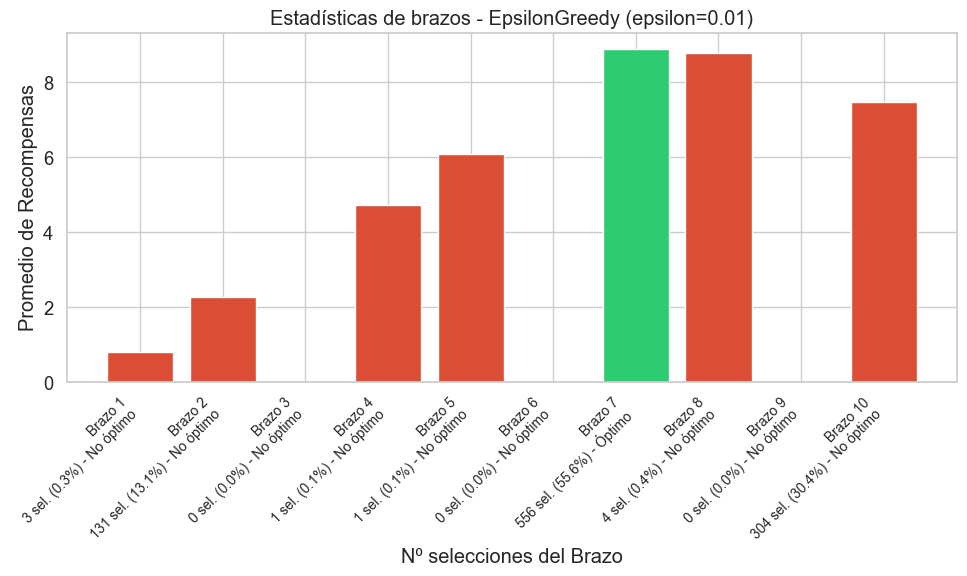

c:\Users\loics\Desktop\Universidad\MasterIA\EML\SalasOrtegaConde1\plotting\plotting.py:136: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(x_labels, rotation=45, ha="right", fontsize=10)



Estadísticas de brazos - EpsilonGreedy (epsilon=0.1)
Brazo 1: Recompensa Promedio = 1.5679, Selecciones = 23
Brazo 2: Recompensa Promedio = 2.1905, Selecciones = 17
Brazo 3: Recompensa Promedio = 1.5831, Selecciones = 8
Brazo 4: Recompensa Promedio = 4.5287, Selecciones = 36
Brazo 5: Recompensa Promedio = 6.5153, Selecciones = 7
Brazo 6: Recompensa Promedio = 8.0347, Selecciones = 7
Brazo 7: Recompensa Promedio = 9.0590, Selecciones = 12
Brazo 8: Recompensa Promedio = 9.5722, Selecciones = 874 (ÓPTIMO)
Brazo 9: Recompensa Promedio = 6.5681, Selecciones = 10
Brazo 10: Recompensa Promedio = 7.3529, Selecciones = 6


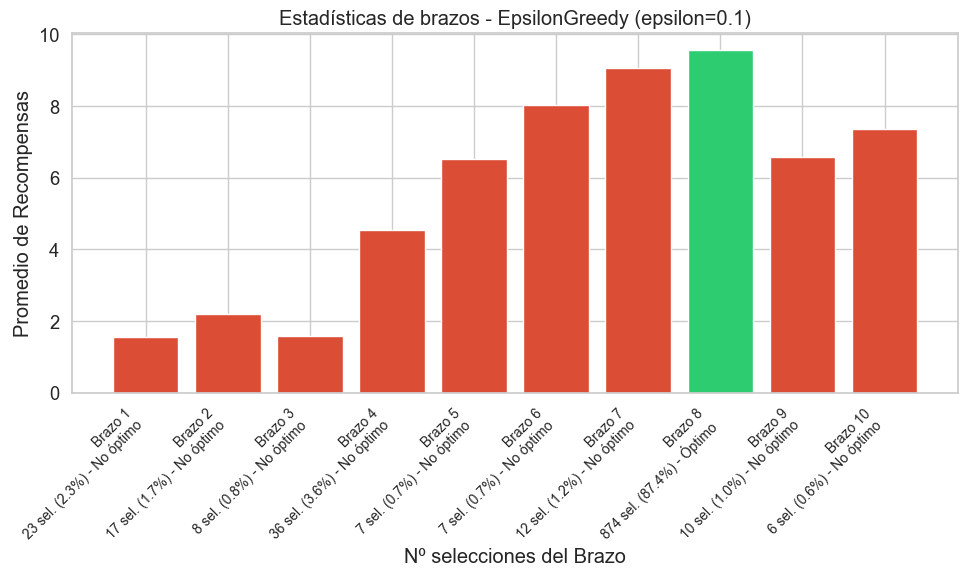

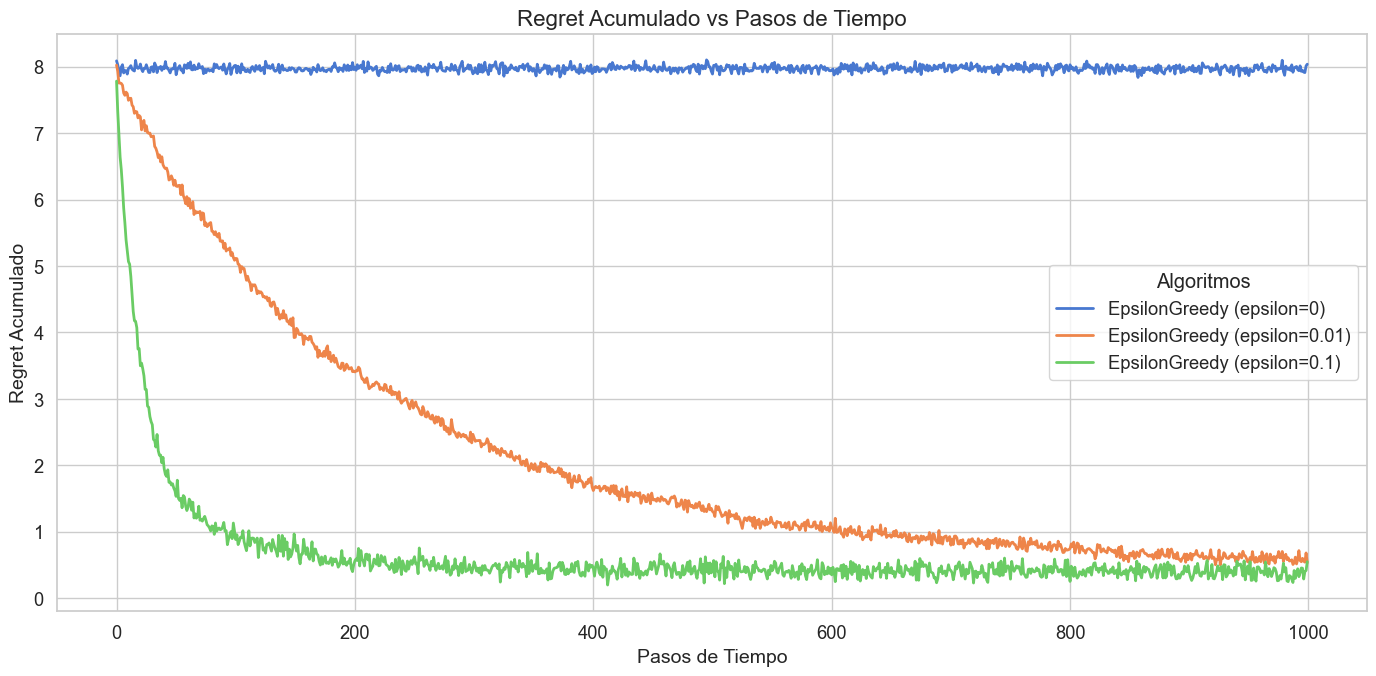

In [5]:
# Graficar los resultados
plot_average_rewards(steps, rewards, algorithms)
plot_optimal_selections(steps, optimal_selections, algorithms)
plot_arm_statistics(arm_stats, algorithms)
plot_regret(steps, regrets, algorithms)

### Análisis

## ``Experimento distribución Bernoulli``

In [6]:
# Creación del bandit
bandit = Bandit(arms=ArmBernoulli.generate_arms(k)) # Generar un bandido con k brazos de distribución de Bernoulli
print(bandit)

optimal_arm = bandit.optimal_arm
print(f"Optimal arm: {optimal_arm + 1} with expected reward={bandit.get_expected_value(optimal_arm)}")

# Definir los algoritmos a comparar. En este caso son 3 algoritmos epsilon-greedy con diferentes valores de epsilon.
algorithms = [EpsilonGreedy(k=k, epsilon=0), EpsilonGreedy(k=k, epsilon=0.01), EpsilonGreedy(k=k, epsilon=0.1)]

# Ejecutar el experimento y obtener las recompensas promedio, porcentaje de selecciones óptimas y estadísticas de brazos
rewards, optimal_selections, arm_stats, regrets = run_experiment(bandit, algorithms, steps, runs)

Bandit with 10 arms: ArmBernoulli(p=0.68), ArmBernoulli(p=0.12), ArmBernoulli(p=0.78), ArmBernoulli(p=0.41), ArmBernoulli(p=0.15), ArmBernoulli(p=0.19), ArmBernoulli(p=0.47), ArmBernoulli(p=0.87), ArmBernoulli(p=0.2), ArmBernoulli(p=0.01)
Optimal arm: 8 with expected reward=0.87


### Visualización

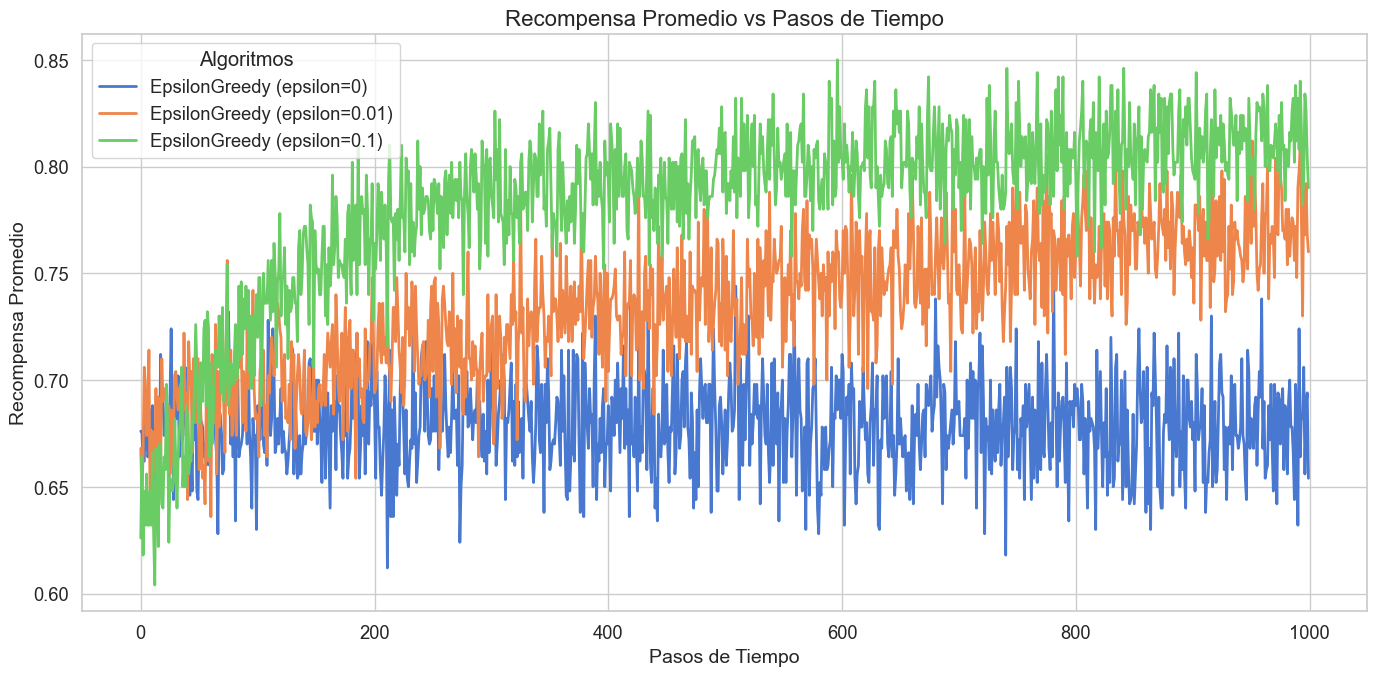

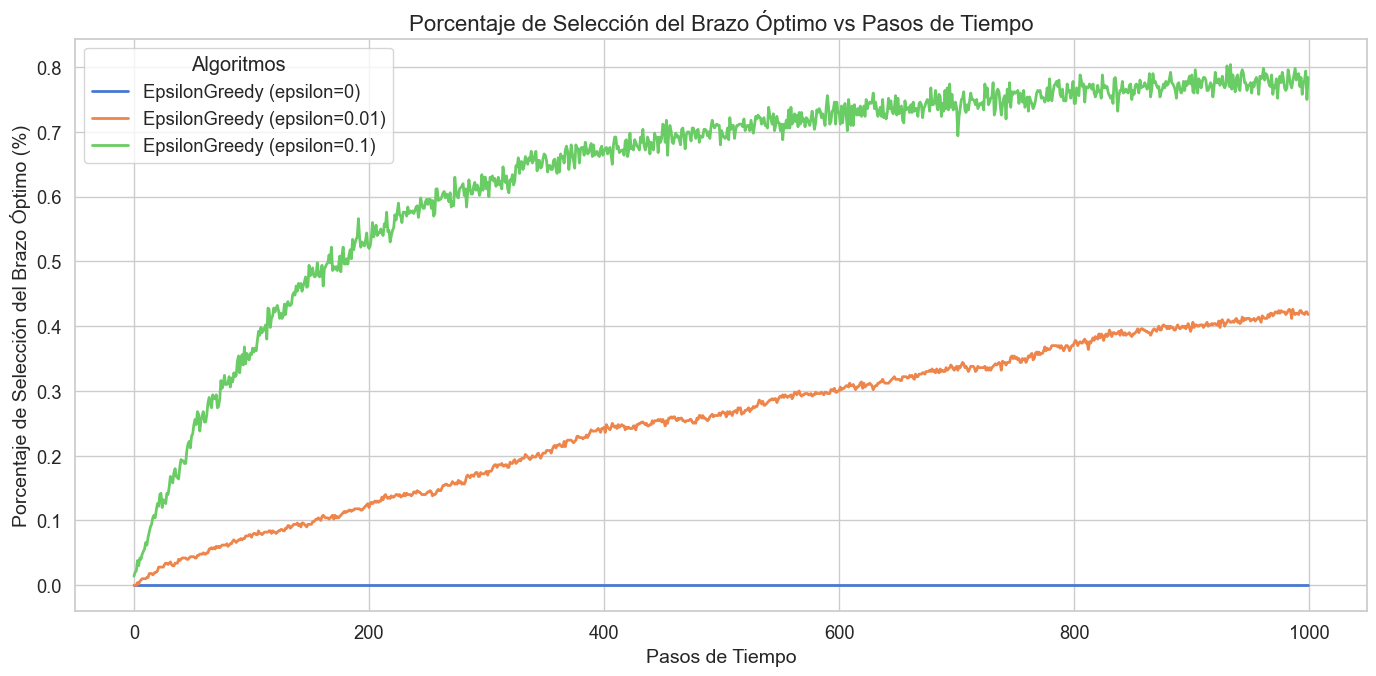


Estadísticas de brazos - EpsilonGreedy (epsilon=0)
Brazo 1: Recompensa Promedio = 0.6420, Selecciones = 1000 (ÓPTIMO)
Brazo 2: Recompensa Promedio = 0.0000, Selecciones = 0
Brazo 3: Recompensa Promedio = 0.0000, Selecciones = 0
Brazo 4: Recompensa Promedio = 0.0000, Selecciones = 0
Brazo 5: Recompensa Promedio = 0.0000, Selecciones = 0
Brazo 6: Recompensa Promedio = 0.0000, Selecciones = 0
Brazo 7: Recompensa Promedio = 0.0000, Selecciones = 0
Brazo 8: Recompensa Promedio = 0.0000, Selecciones = 0
Brazo 9: Recompensa Promedio = 0.0000, Selecciones = 0
Brazo 10: Recompensa Promedio = 0.0000, Selecciones = 0


c:\Users\loics\Desktop\Universidad\MasterIA\EML\SalasOrtegaConde1\plotting\plotting.py:136: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(x_labels, rotation=45, ha="right", fontsize=10)


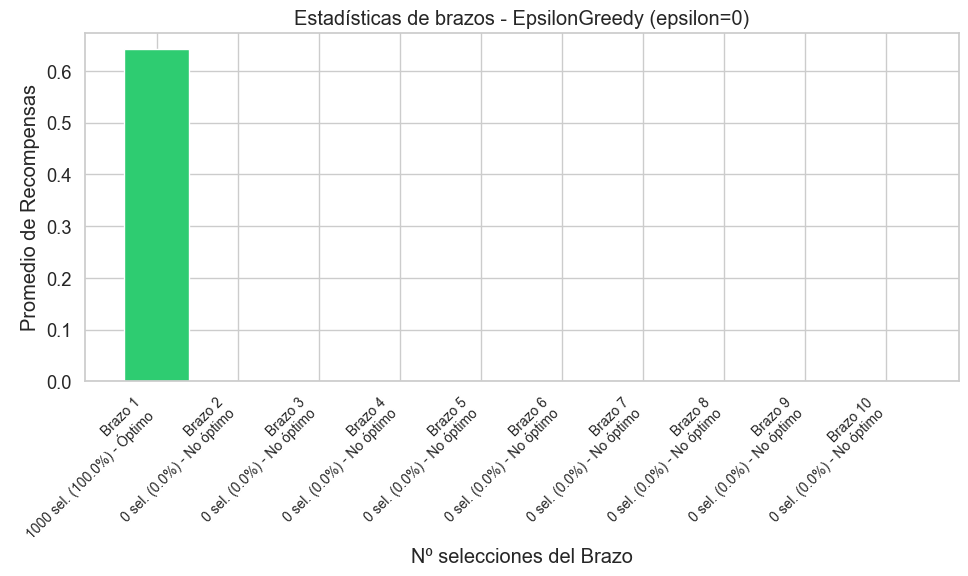


Estadísticas de brazos - EpsilonGreedy (epsilon=0.01)
Brazo 1: Recompensa Promedio = 0.6566, Selecciones = 364
Brazo 2: Recompensa Promedio = 0.0000, Selecciones = 1
Brazo 3: Recompensa Promedio = 0.0000, Selecciones = 0
Brazo 4: Recompensa Promedio = 0.7143, Selecciones = 7
Brazo 5: Recompensa Promedio = 0.0000, Selecciones = 2
Brazo 6: Recompensa Promedio = 0.3333, Selecciones = 3
Brazo 7: Recompensa Promedio = 0.0000, Selecciones = 2
Brazo 8: Recompensa Promedio = 0.8903, Selecciones = 620 (ÓPTIMO)
Brazo 9: Recompensa Promedio = 0.0000, Selecciones = 1
Brazo 10: Recompensa Promedio = 0.0000, Selecciones = 0


c:\Users\loics\Desktop\Universidad\MasterIA\EML\SalasOrtegaConde1\plotting\plotting.py:136: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(x_labels, rotation=45, ha="right", fontsize=10)


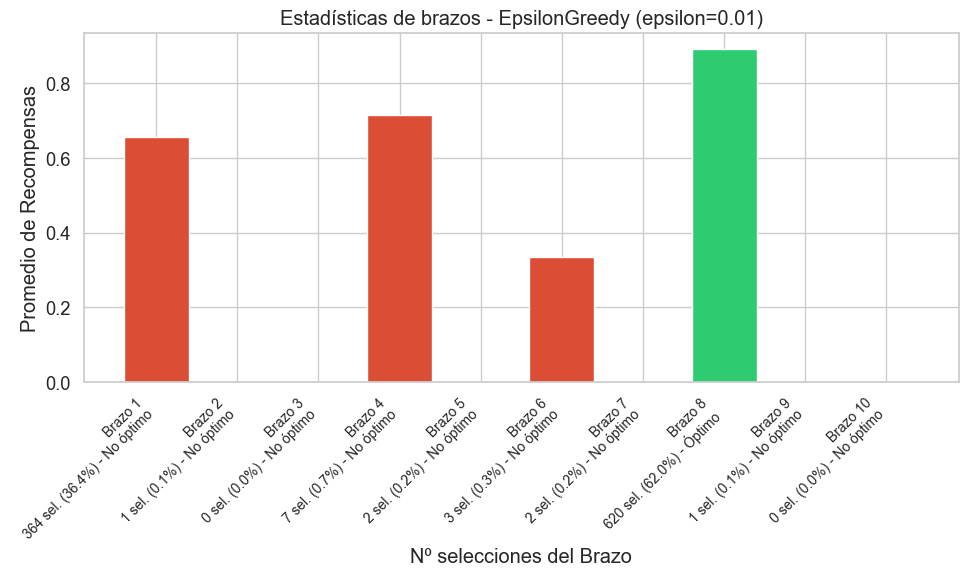

c:\Users\loics\Desktop\Universidad\MasterIA\EML\SalasOrtegaConde1\plotting\plotting.py:136: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(x_labels, rotation=45, ha="right", fontsize=10)



Estadísticas de brazos - EpsilonGreedy (epsilon=0.1)
Brazo 1: Recompensa Promedio = 0.6992, Selecciones = 123
Brazo 2: Recompensa Promedio = 0.1000, Selecciones = 10
Brazo 3: Recompensa Promedio = 0.4444, Selecciones = 9
Brazo 4: Recompensa Promedio = 0.3750, Selecciones = 8
Brazo 5: Recompensa Promedio = 0.1429, Selecciones = 14
Brazo 6: Recompensa Promedio = 0.2500, Selecciones = 4
Brazo 7: Recompensa Promedio = 0.2000, Selecciones = 10
Brazo 8: Recompensa Promedio = 0.8784, Selecciones = 806 (ÓPTIMO)
Brazo 9: Recompensa Promedio = 0.2857, Selecciones = 7
Brazo 10: Recompensa Promedio = 0.0000, Selecciones = 9


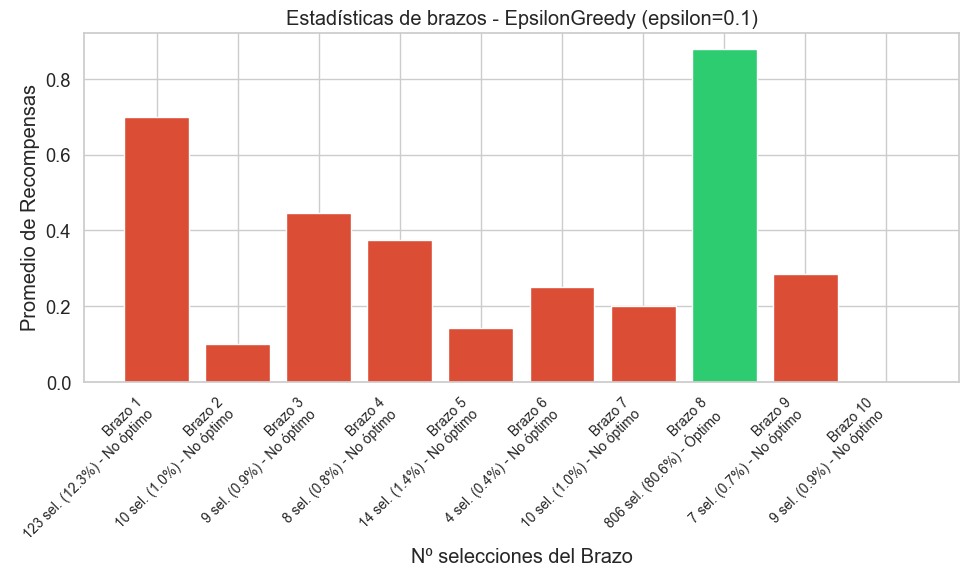

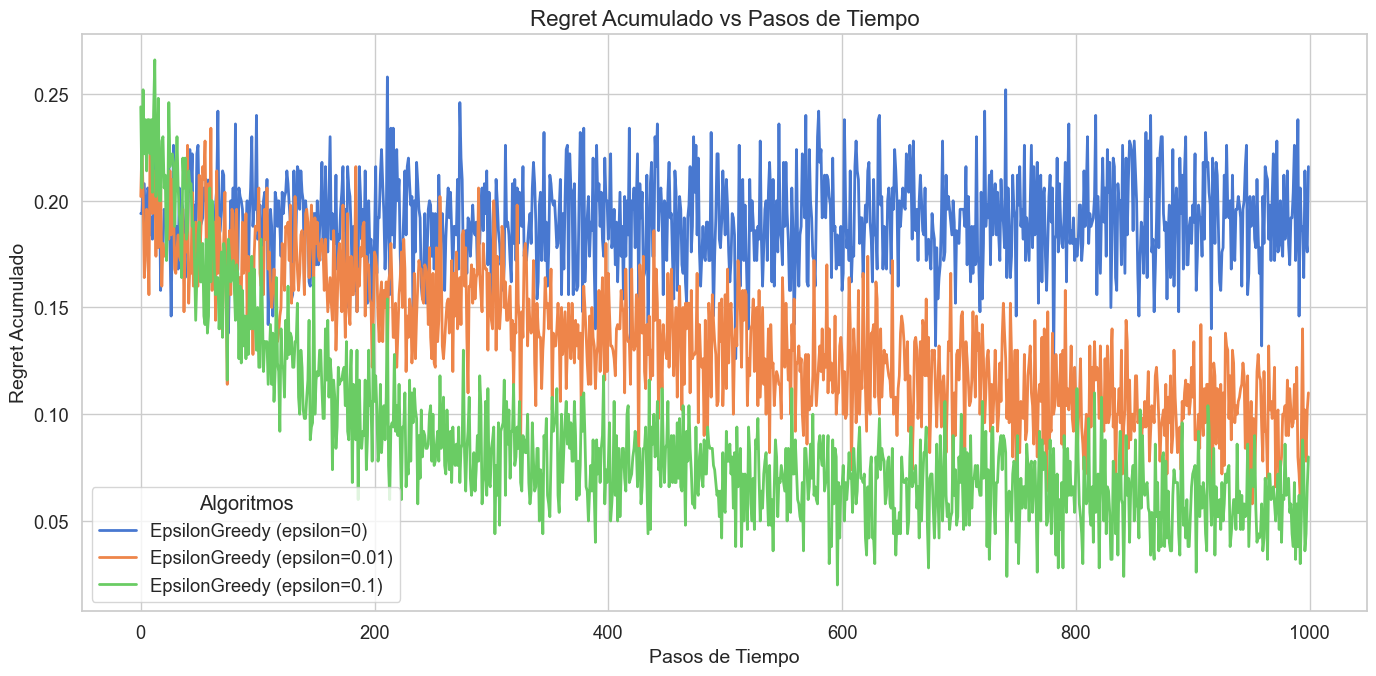

In [7]:
# Graficar los resultados
plot_average_rewards(steps, rewards, algorithms)
plot_optimal_selections(steps, optimal_selections, algorithms)
plot_arm_statistics(arm_stats, algorithms)
plot_regret(steps, regrets, algorithms)

### Análisis

## ``Experimento distribución Binomial``

In [8]:
# Creación del bandit
bandit = Bandit(arms=ArmBinomial.generate_arms(k)) # Generar un bandido con k brazos de distribución binomial
print(bandit)

optimal_arm = bandit.optimal_arm
print(f"Optimal arm: {optimal_arm + 1} with expected reward={bandit.get_expected_value(optimal_arm)}")

# Definir los algoritmos a comparar. En este caso son 3 algoritmos epsilon-greedy con diferentes valores de epsilon.
algorithms = [EpsilonGreedy(k=k, epsilon=0), EpsilonGreedy(k=k, epsilon=0.01), EpsilonGreedy(k=k, epsilon=0.1)]

# Ejecutar el experimento y obtener las recompensas promedio, porcentaje de selecciones óptimas y estadísticas de brazos
rewards, optimal_selections, arm_stats, regrets = run_experiment(bandit, algorithms, steps, runs)

Bandit with 10 arms: ArmBinomial(n=10, p=0.75), ArmBinomial(n=10, p=0.72), ArmBinomial(n=10, p=0.06), ArmBinomial(n=10, p=0.25), ArmBinomial(n=10, p=0.19), ArmBinomial(n=10, p=0.85), ArmBinomial(n=10, p=0.13), ArmBinomial(n=10, p=0.18), ArmBinomial(n=10, p=0.61), ArmBinomial(n=10, p=0.28)
Optimal arm: 6 with expected reward=8.5


### Visualización

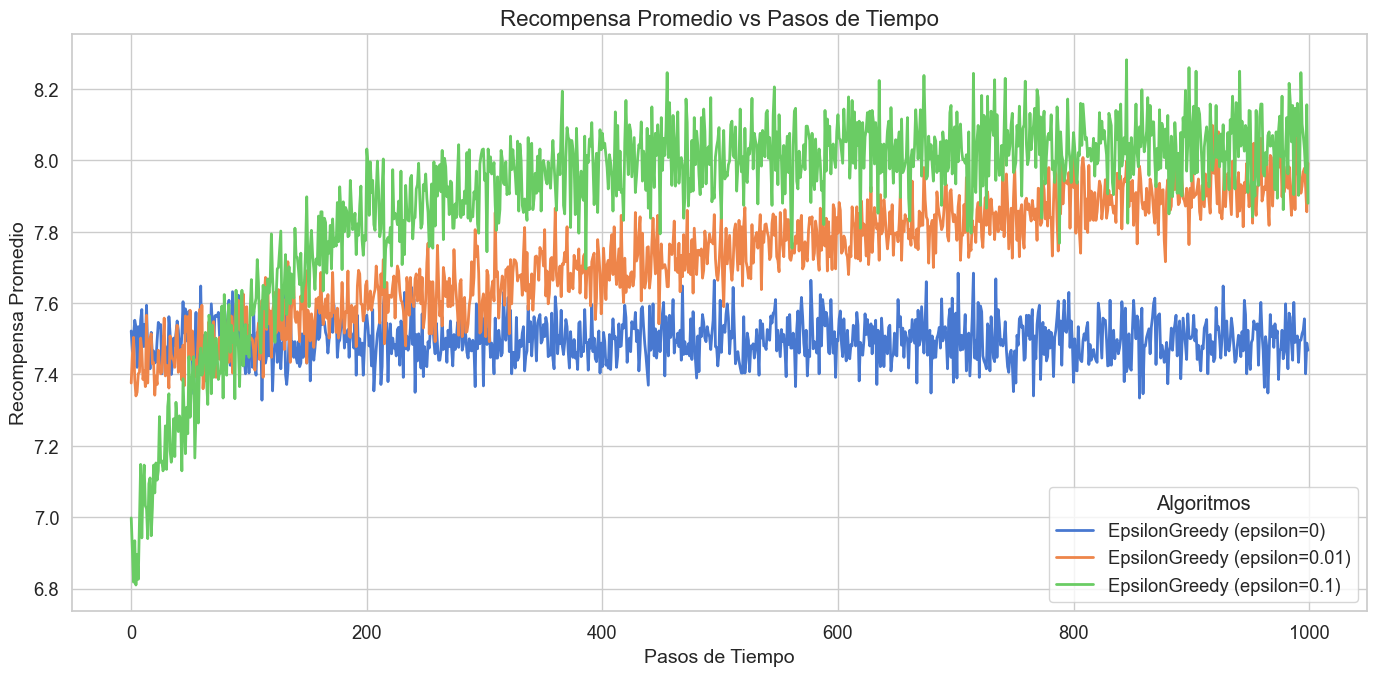

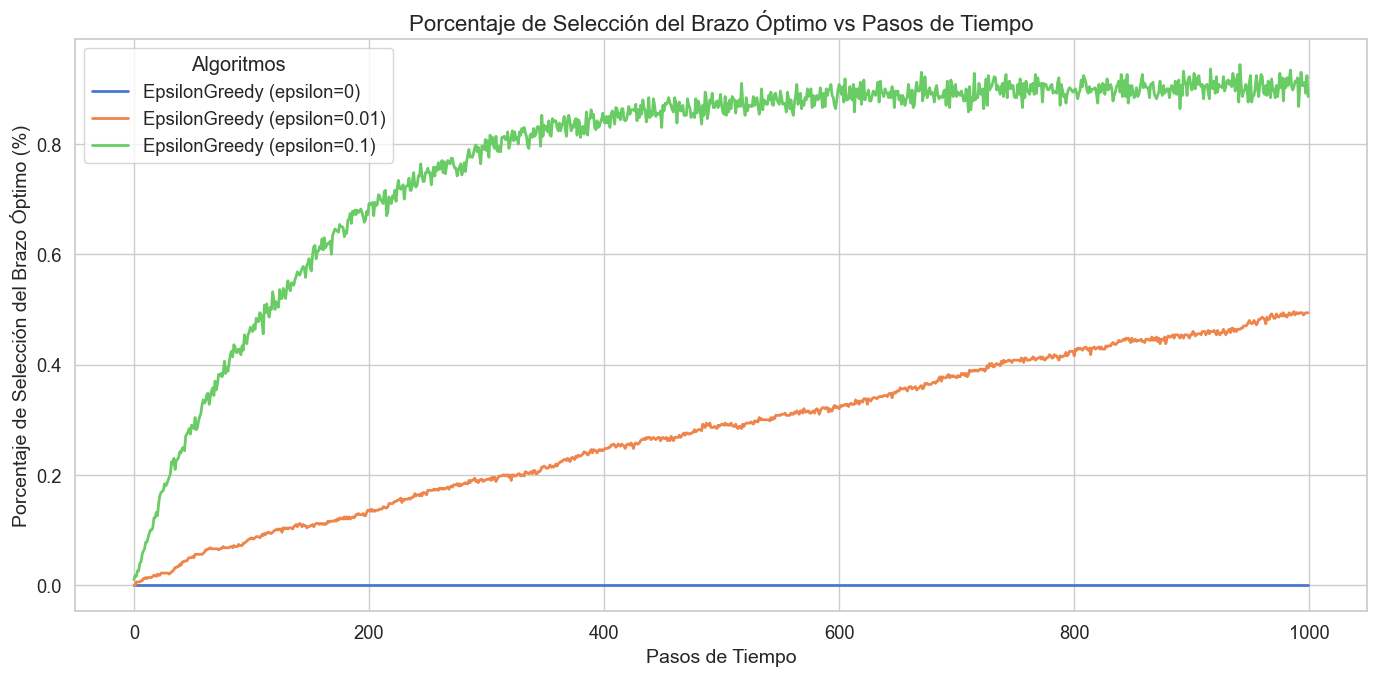


Estadísticas de brazos - EpsilonGreedy (epsilon=0)
Brazo 1: Recompensa Promedio = 7.5050, Selecciones = 1000 (ÓPTIMO)
Brazo 2: Recompensa Promedio = 0.0000, Selecciones = 0
Brazo 3: Recompensa Promedio = 0.0000, Selecciones = 0
Brazo 4: Recompensa Promedio = 0.0000, Selecciones = 0
Brazo 5: Recompensa Promedio = 0.0000, Selecciones = 0
Brazo 6: Recompensa Promedio = 0.0000, Selecciones = 0
Brazo 7: Recompensa Promedio = 0.0000, Selecciones = 0
Brazo 8: Recompensa Promedio = 0.0000, Selecciones = 0
Brazo 9: Recompensa Promedio = 0.0000, Selecciones = 0
Brazo 10: Recompensa Promedio = 0.0000, Selecciones = 0


c:\Users\loics\Desktop\Universidad\MasterIA\EML\SalasOrtegaConde1\plotting\plotting.py:136: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(x_labels, rotation=45, ha="right", fontsize=10)


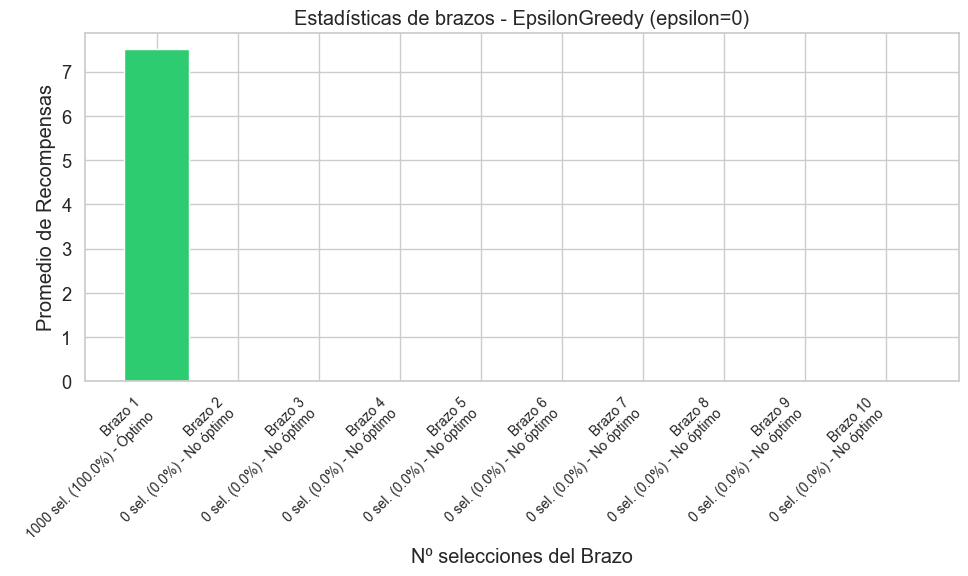


Estadísticas de brazos - EpsilonGreedy (epsilon=0.01)
Brazo 1: Recompensa Promedio = 7.5344, Selecciones = 610
Brazo 2: Recompensa Promedio = 8.0000, Selecciones = 1
Brazo 3: Recompensa Promedio = 1.0000, Selecciones = 1
Brazo 4: Recompensa Promedio = 0.0000, Selecciones = 0
Brazo 5: Recompensa Promedio = 2.0000, Selecciones = 2
Brazo 6: Recompensa Promedio = 8.4360, Selecciones = 383 (ÓPTIMO)
Brazo 7: Recompensa Promedio = 1.0000, Selecciones = 1
Brazo 8: Recompensa Promedio = 0.0000, Selecciones = 0
Brazo 9: Recompensa Promedio = 5.5000, Selecciones = 2
Brazo 10: Recompensa Promedio = 0.0000, Selecciones = 0


c:\Users\loics\Desktop\Universidad\MasterIA\EML\SalasOrtegaConde1\plotting\plotting.py:136: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(x_labels, rotation=45, ha="right", fontsize=10)


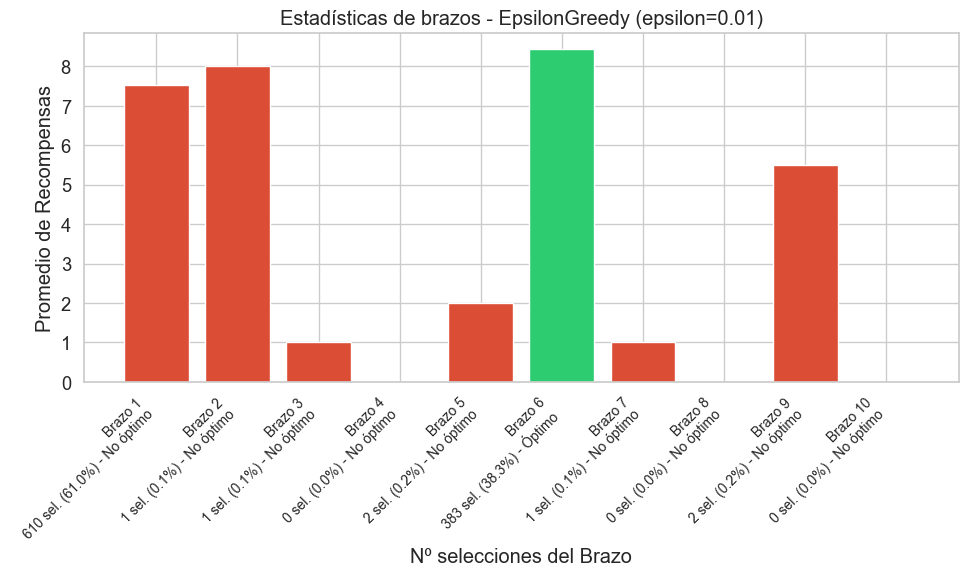

c:\Users\loics\Desktop\Universidad\MasterIA\EML\SalasOrtegaConde1\plotting\plotting.py:136: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(x_labels, rotation=45, ha="right", fontsize=10)



Estadísticas de brazos - EpsilonGreedy (epsilon=0.1)
Brazo 1: Recompensa Promedio = 7.5216, Selecciones = 487
Brazo 2: Recompensa Promedio = 7.3182, Selecciones = 22
Brazo 3: Recompensa Promedio = 0.6000, Selecciones = 10
Brazo 4: Recompensa Promedio = 2.8667, Selecciones = 15
Brazo 5: Recompensa Promedio = 2.0909, Selecciones = 11
Brazo 6: Recompensa Promedio = 8.4444, Selecciones = 414 (ÓPTIMO)
Brazo 7: Recompensa Promedio = 1.2143, Selecciones = 14
Brazo 8: Recompensa Promedio = 2.1429, Selecciones = 7
Brazo 9: Recompensa Promedio = 6.8462, Selecciones = 13
Brazo 10: Recompensa Promedio = 2.5714, Selecciones = 7


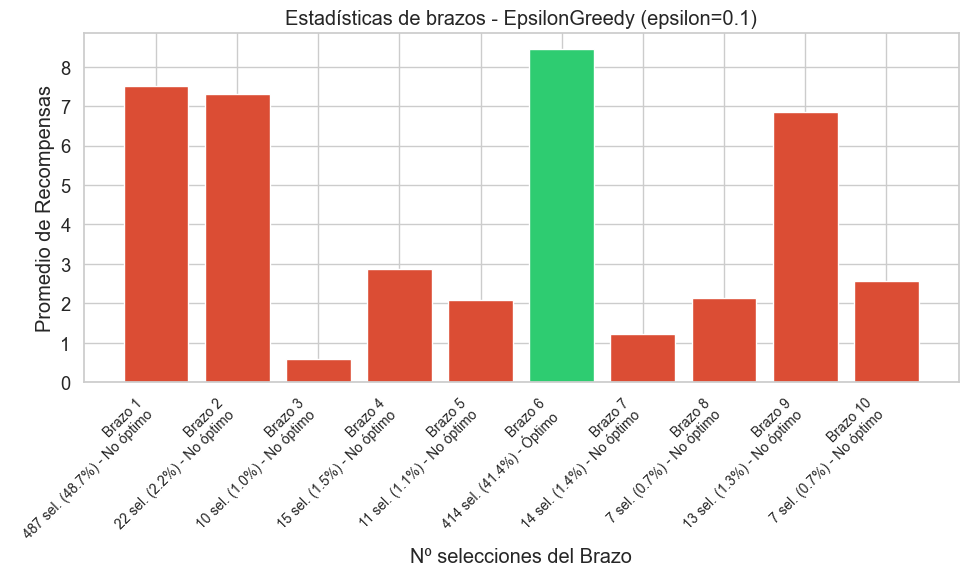

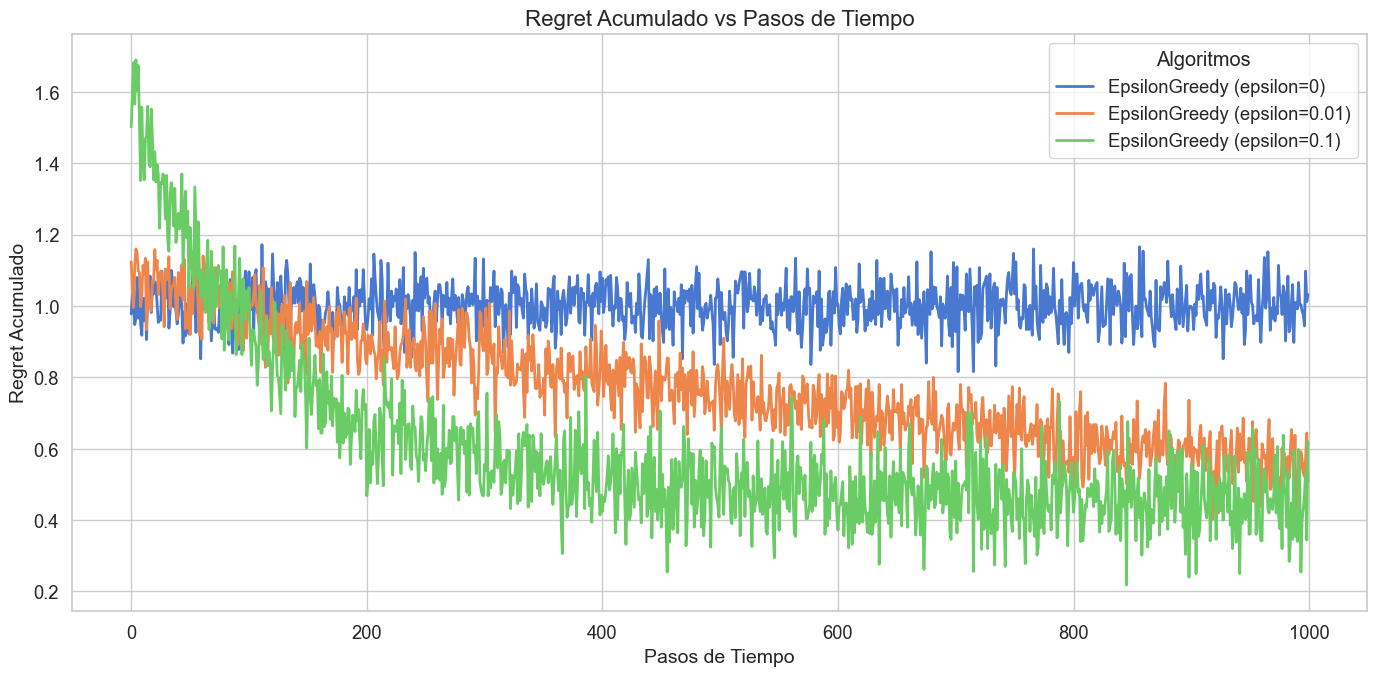

In [9]:
# Graficar los resultados
plot_average_rewards(steps, rewards, algorithms)
plot_optimal_selections(steps, optimal_selections, algorithms)
plot_arm_statistics(arm_stats, algorithms)
plot_regret(steps, regrets, algorithms)

### Análisis